# Beat Tracking and Chord Recognition

The goal of this homework is to implement classic approaches for beat tracking and chord recognition. Through this assignment, you are expected to develop a solid understanding of onset and chroma audio features, as well as fundamental sequence modeling algorithms such as Dynamic Programming and Hidden Markov Models (HMMs). In addition, you will improve the accuracy of the basic configuration with your ideas.

## Load a music track with its beat and chord annotation

In [1]:
# %%capture prevents the output log from displaying in this cell. If you want to see the log, remove %%capture below.
# %%capture

# !pip install libfmp
# !pip install mir_eval

import librosa
import requests
import io
import IPython.display as ipd
import numpy as np

from matplotlib import pyplot as plt

import libfmp.b
import libfmp.c2
import libfmp.c3
import libfmp.c4
import libfmp.c5
import libfmp.c6
import mir_eval

import pandas as pd


Let's first load Beatles' Let It Be and listen to it.

In [2]:
# audio_url = "https://www.audiolabs-erlangen.de/resources/MIR/FMP/data/C5/FMP_C5_Audio_Beatles_LetItBe_Beatles_1970-LetItBe-06.wav"
# response = requests.get(audio_url)
# audio_bytes = io.BytesIO(response.content)
# y, sr = librosa.load(audio_bytes)

AUDIO_PATH = "audio/FMP_C5_Audio_Beatles_LetItBe_Beatles_1970-LetItBe-06.wav"

y, sr = librosa.load(AUDIO_PATH, sr=None)

# take the first 30 seconds
y_slice = y[:30*sr]

# ipd.Audio(y_slice, rate=sr)

Let's visualize the beat and chord labels. Also, let's listen to the beats as a series of click sounds.

<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1719906/2227099370.py:4: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(io.BytesIO(response.content), sep='\s+', header=None, comment='[', usecols=[0])


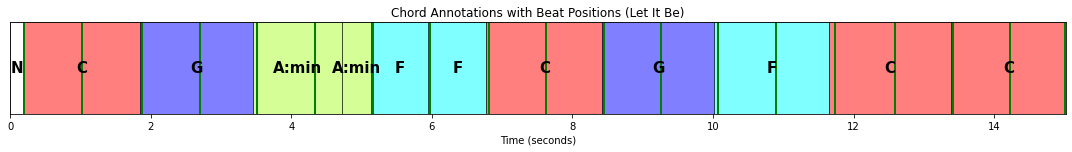

In [3]:
# get beat labels
beat_label_url = "https://isophonics.net/files/annotations/beat/The%20Beatles/12_-_Let_It_Be/06_-_Let_It_Be.txt"
response = requests.get(beat_label_url)
df = pd.read_csv(io.BytesIO(response.content), sep='\s+', header=None, comment='[', usecols=[0])
gt_beat_label = df.values.flatten()

# get chord labels
chord_label_url = "https://www.audiolabs-erlangen.de/resources/MIR/FMP/data/C5/FMP_C5_Audio_Beatles_LetItBe_Beatles_1970-LetItBe-06_Chords_simplified.csv"
response = requests.get(chord_label_url)
gt_chord_label, _ = libfmp.c4.read_structure_annotation(io.BytesIO(response.content))

# plot chord annotations
color_ann = {'N': 'white',
             'C': 'red', 'C#': 'peru', 'D': 'orange', 'D#': 'yellow', 'Eb': 'yellow',
             'E': 'springgreen', 'F': 'cyan', 'F#': 'coral', 'G': 'blue',
             'G#': 'olive', 'A': 'teal', 'A#': 'indigo', 'Bb': 'indigo', 'B': 'pink',
             'C#:min': 'steelblue', 'C#m': 'steelblue', 'A:min': 'greenyellow', 'A:m': 'greenyellow',
             'G:min': 'olive', 'E:min': 'lightcoral', 'B:min': 'saddlebrown'}

# visualize chords blocks
fig, ax = libfmp.b.plot_segments(gt_chord_label[:12], figsize=(15, 2), time_label='Time (seconds)',
                       fontsize=15, colors=color_ann, alpha=0.5)

# plot beat positions
ax.vlines(gt_beat_label, ymin=0, ymax=1, color='Green', linestyle='-', linewidth=2, alpha=1, label='Beats')

plt.title('Chord Annotations with Beat Positions (Let It Be)')
plt.show()

# sonify the estimated beat
gt_beat_label_slice = gt_beat_label[(gt_beat_label >= 0) & (gt_beat_label <= 30)]
y_beats = librosa.clicks(times=gt_beat_label_slice, sr=sr, click_freq=1000, length=len(y_slice))
# ipd.display(ipd.Audio(y_slice + y_beats, rate=sr))

## Beat Tracking By Dynamic Programing

Let's do beat tracking on the intro part which does not have vocal sources.

predicted tempo (BPM) [71.77734375]


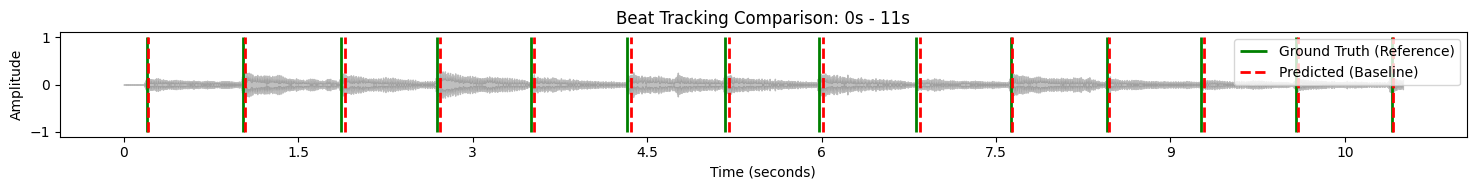

MIR Evaluation Metric     | Score     
----------------------------------------
F-measure                 | 1.0000
CMLc (Correct Cont.)      | 1.0000
CMLt (Correct Total)      | 1.0000
AMLc (Any Metric Cont.)   | 1.0000
AMLt (Any Metric Total)   | 1.0000


In [4]:
# get the audio file
# audio_url = "https://www.audiolabs-erlangen.de/resources/MIR/FMP/data/C5/FMP_C5_Audio_Beatles_LetItBe_Beatles_1970-LetItBe-06.wav"
# response = requests.get(audio_url)
# audio_bytes = io.BytesIO(response.content)

# take the intro part (piano only)
start_sec = 0
duration = 11
# y_slice, _ = librosa.load(audio_bytes, sr=sr, offset=start_sec, duration=duration)
y_slice, _ = librosa.load(AUDIO_PATH, sr=sr, offset=start_sec, duration=duration)
gt_beats_slice = gt_beat_label[(gt_beat_label >= start_sec) & (gt_beat_label <= start_sec + duration)] - start_sec

# run the beat tracking
onset_env = librosa.onset.onset_strength(y=y_slice, sr=sr)
tempo_pred, beat_frames_pred = librosa.beat.beat_track(onset_envelope=onset_env, sr=sr)
pred_beats_slice = librosa.frames_to_time(beat_frames_pred, sr=sr)

# print tempo
print('predicted tempo (BPM)', tempo_pred)

# plot the ground truth beats and predicted beats
plt.figure(figsize=(15, 2))
librosa.display.waveshow(y_slice, sr=sr, alpha=0.5, color='gray')
plt.vlines(gt_beats_slice, -1, 1, color='g', linestyle='-', linewidth=2, label='Ground Truth (Reference)')
plt.vlines(pred_beats_slice, -1, 1, color='r', linestyle='--', linewidth=2, label='Predicted (Baseline)')
plt.title(f'Beat Tracking Comparison: {start_sec}s - {start_sec + duration}s')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

# report the result using "mir_eval"
scores = mir_eval.beat.evaluate(gt_beats_slice, pred_beats_slice)

print("="*40)
print(f"{'MIR Evaluation Metric':<25} | {'Score':<10}")
print("-"*40)
print(f"{'F-measure':<25} | {scores['F-measure']:.4f}")
print(f"{'CMLc (Correct Cont.)':<25} | {scores['Correct Metric Level Continuous']:.4f}")
print(f"{'CMLt (Correct Total)':<25} | {scores['Correct Metric Level Total']:.4f}")
print(f"{'AMLc (Any Metric Cont.)':<25} | {scores['Any Metric Level Continuous']:.4f}")
print(f"{'AMLt (Any Metric Total)':<25} | {scores['Any Metric Level Total']:.4f}")
print("="*40)


# sonify the estimated beat
y_beats = librosa.clicks(times=pred_beats_slice, sr=sr, click_freq=1000, length=len(y_slice))
# ipd.display(ipd.Audio(y_slice + y_beats, rate=sr))

The simple implementation works perfectly on the intro part that has only piano.

Let's take the vocal part and use the same beat tracking code.

predicted tempo (BPM) [143.5546875]


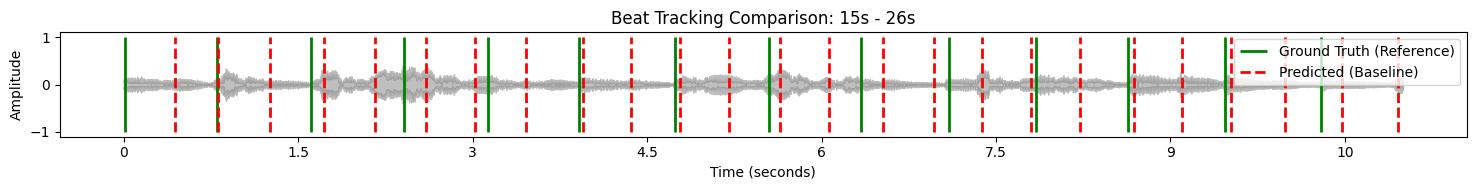

MIR Evaluation Metric     | Score     
----------------------------------------
F-measure                 | 0.2857
CMLc (Correct Cont.)      | 0.0000
CMLt (Correct Total)      | 0.0000
AMLc (Any Metric Cont.)   | 0.3571
AMLt (Any Metric Total)   | 0.3571


In [8]:
# get the audio file
# audio_url = "https://www.audiolabs-erlangen.de/resources/MIR/FMP/data/C5/FMP_C5_Audio_Beatles_LetItBe_Beatles_1970-LetItBe-06.wav"
# response = requests.get(audio_url)
# audio_bytes = io.BytesIO(response.content)

# take the verse part (vocal + piano)
start_sec = 15
duration = 11
# y_slice, _ = librosa.load(audio_bytes, sr=sr, offset=start_sec, duration=duration)
y_slice, _ = librosa.load(AUDIO_PATH, sr=sr, offset=start_sec, duration=duration)
gt_beats_slice = gt_beat_label[(gt_beat_label >= start_sec) & (gt_beat_label <= start_sec + duration)] - start_sec

# run the beat tracking
onset_env = librosa.onset.onset_strength(y=y_slice, sr=sr)
tempo_pred, beat_frames_pred = librosa.beat.beat_track(onset_envelope=onset_env, sr=sr)
pred_beats_slice = librosa.frames_to_time(beat_frames_pred, sr=sr)

# print tempo
print('predicted tempo (BPM)', tempo_pred)

# plot the ground truth beats and predicted beats
plt.figure(figsize=(15, 2))
librosa.display.waveshow(y_slice, sr=sr, alpha=0.5, color='gray')
plt.vlines(gt_beats_slice, -1, 1, color='g', linestyle='-', linewidth=2, label='Ground Truth (Reference)')
plt.vlines(pred_beats_slice, -1, 1, color='r', linestyle='--', linewidth=2, label='Predicted (Baseline)')
plt.title(f'Beat Tracking Comparison: {start_sec}s - {start_sec + duration}s')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

# report the result using "mir_eval"
scores = mir_eval.beat.evaluate(gt_beats_slice, pred_beats_slice)

print("="*40)
print(f"{'MIR Evaluation Metric':<25} | {'Score':<10}")
print("-"*40)
print(f"{'F-measure':<25} | {scores['F-measure']:.4f}")
print(f"{'CMLc (Correct Cont.)':<25} | {scores['Correct Metric Level Continuous']:.4f}")
print(f"{'CMLt (Correct Total)':<25} | {scores['Correct Metric Level Total']:.4f}")
print(f"{'AMLc (Any Metric Cont.)':<25} | {scores['Any Metric Level Continuous']:.4f}")
print(f"{'AMLt (Any Metric Total)':<25} | {scores['Any Metric Level Total']:.4f}")
print("="*40)


# sonify the estimated beat
y_beats = librosa.clicks(times=pred_beats_slice, sr=sr, click_freq=1000, length=len(y_slice))
# ipd.display(ipd.Audio(y_slice + y_beats, rate=sr))


The accuracy is aweful! Why the tmepo increases a lot? How can you improve the performance?

## Implementing HPSS

In [9]:
from scipy import signal

def convert_l_sec_to_frames(L_h_sec, sr=22050, n_fft=1024, hop_length=512):
    L_h = int(np.ceil(L_h_sec * sr / hop_length))
    return L_h

def convert_l_hertz_to_bins(L_p_Hz, sr=22050, n_fft=1024, hop_length=512):
    L_p = int(np.ceil(L_p_Hz * n_fft / sr))
    return L_p

def make_integer_odd(n):
    if n % 2 == 0:
        n += 1
    return n

def hpss(x, sr, n_fft, hop_length, L_h, L_p, L_unit='physical', mask='binary', eps=0.001, detail=False):
    """
    L_h: median filter length for harmonic component
    L_p: median filter length for percussive component
    L_unit: unit of L_h and L_p, either 'physical' (seconds for L_h and Hz for L_p) or 'indices' (number of frames for L_h and number of frequency bins for L_p)
    mask: type of mask, either 'binary' or 'soft'
    eps: small constant for numerical stability in soft masking
    """
    assert L_unit in ['physical', 'indices']
    assert mask in ['binary', 'soft']
    # stft
    X = librosa.stft(x, n_fft=n_fft, hop_length=hop_length, win_length=n_fft, window='hann', center=True, pad_mode='constant')
    # power spectrogram
    Y = np.abs(X) ** 2
    # median filtering
    if L_unit == 'physical':
        L_h = convert_l_sec_to_frames(L_h_sec=L_h, sr=sr, n_fft=n_fft, hop_length=hop_length)
        L_p = convert_l_hertz_to_bins(L_p_Hz=L_p, sr=sr, n_fft=n_fft, hop_length=hop_length)
    L_h = make_integer_odd(L_h)
    L_p = make_integer_odd(L_p)
    Y_h = signal.medfilt(Y, [1, L_h])
    Y_p = signal.medfilt(Y, [L_p, 1])

    # masking
    if mask == 'binary':
        M_h = np.int8(Y_h >= Y_p)
        M_p = np.int8(Y_h < Y_p)
    if mask == 'soft':
        M_h = (Y_h + eps / 2) / (Y_h + Y_p + eps)
        M_p = (Y_p + eps / 2) / (Y_h + Y_p + eps)
    X_h = X * M_h
    X_p = X * M_p

    # istft
    x_h = librosa.istft(X_h, hop_length=hop_length, win_length=n_fft, window='hann', center=True, length=x.size)
    x_p = librosa.istft(X_p, hop_length=hop_length, win_length=n_fft, window='hann', center=True, length=x.size)

    if detail:
        return x_h, x_p, dict(Y_h=Y_h, Y_p=Y_p, M_h=M_h, M_p=M_p, X_h=X_h, X_p=X_p)
    else:
        return x_h, x_p

In [17]:
# HPSS parameter experiments on the verse section
# The baseline uses the full mixture. Each HPSS run tracks beats on the percussive component.

start_sec = 15
duration = 11
n_fft = 1024
hop_length = 512

y_verse, _ = librosa.load(AUDIO_PATH, sr=sr, offset=start_sec, duration=duration)
gt_beats_verse = gt_beat_label[(gt_beat_label >= start_sec) & (gt_beat_label <= start_sec + duration)] - start_sec


def run_beat_tracking_eval(x, label):
    onset_env = librosa.onset.onset_strength(y=x, sr=sr, hop_length=hop_length)
    tempo, beat_frames = librosa.beat.beat_track(onset_envelope=onset_env, sr=sr, hop_length=hop_length)
    beat_times = librosa.frames_to_time(beat_frames, sr=sr, hop_length=hop_length)
    scores = mir_eval.beat.evaluate(gt_beats_verse, beat_times)

    return {
        'setting': label,
        'tempo': float(np.atleast_1d(tempo)[0]),
        'n_beats': len(beat_times),
        'beat_times': beat_times,
        'F-measure': scores['F-measure'],
        'CMLc': scores['Correct Metric Level Continuous'],
        'CMLt': scores['Correct Metric Level Total'],
        'AMLc': scores['Any Metric Level Continuous'],
        'AMLt': scores['Any Metric Level Total'],
    }


baseline_result = run_beat_tracking_eval(y_verse, 'baseline mixture')

hpss_param_candidates = {
    'L_h': [0.10, 0.20, 0.40],  # in seconds
    'L_p': [300, 500, 900],  # in Hz
    'mask': ['binary', 'soft'],
}

hpss_param_grid = []
for L_h in hpss_param_candidates['L_h']:
    for L_p in hpss_param_candidates['L_p']:
        for mask in hpss_param_candidates['mask']:
            hpss_param_grid.append({'L_h': L_h, 'L_p': L_p, 'mask': mask})

hpss_results = []
separated_audio = {}

for params in hpss_param_grid:
    label = f"L_h={params['L_h']}s, L_p={params['L_p']}Hz, {params['mask']}"
    y_h, y_p = hpss(
        y_verse,
        sr=sr,
        n_fft=n_fft,
        hop_length=hop_length,
        L_h=params['L_h'],
        L_p=params['L_p'],
        L_unit='physical',
        mask=params['mask'],
    )
    result = run_beat_tracking_eval(y_p, label)
    result.update(params)
    hpss_results.append(result)
    separated_audio[label] = (y_h, y_p)

results_df = pd.DataFrame([baseline_result] + hpss_results)
metric_cols = ['tempo', 'n_beats', 'F-measure', 'CMLc', 'CMLt', 'AMLc', 'AMLt']
summary_df = results_df[['setting', 'L_h', 'L_p', 'mask'] + metric_cols].copy()
summary_df['F improvement'] = summary_df['F-measure'] - baseline_result['F-measure']
summary_df['CMLc improvement'] = summary_df['CMLc'] - baseline_result['CMLc']
summary_df = summary_df.sort_values('F-measure', ascending=False)

display(summary_df.style.format({
    'L_h': '{:.2f}',
    'tempo': '{:.2f}',
    'F-measure': '{:.4f}',
    'CMLc': '{:.4f}',
    'CMLt': '{:.4f}',
    'AMLc': '{:.4f}',
    'AMLt': '{:.4f}',
    'F improvement': '{:+.4f}',
    'CMLc improvement': '{:+.4f}',
}))

best = summary_df.iloc[0]
best_result = results_df.loc[results_df['setting'] == best['setting']].iloc[0]

print(f"Baseline verse F-measure: {baseline_result['F-measure']:.4f}, CMLc: {baseline_result['CMLc']:.4f}, tempo: {baseline_result['tempo']:.2f} BPM")
print(f"Best HPSS setting: {best['setting']}")
print(f"Best HPSS F-measure: {best_result['F-measure']:.4f} ({best['F improvement']:+.4f}), CMLc: {best_result['CMLc']:.4f} ({best['CMLc improvement']:+.4f}), tempo: {best_result['tempo']:.2f} BPM")

hpss_results_df = pd.DataFrame(hpss_results)
param_effect = (
    hpss_results_df
    .groupby(['mask', 'L_h', 'L_p'])[['F-measure', 'CMLc', 'AMLt']]
    .mean()
    .sort_values('F-measure', ascending=False)
)
print('\nParameter combinations ranked by average F-measure:')
display(param_effect.style.format('{:.4f}'))

marginal_rows = []
for parameter in ['mask', 'L_h', 'L_p']:
    means = hpss_results_df.groupby(parameter)['F-measure'].mean().sort_values(ascending=False)
    for value, mean_score in means.items():
        marginal_rows.append({'parameter': parameter, 'value': value, 'mean F-measure': mean_score})
marginal_effect = pd.DataFrame(marginal_rows)

print('\nMarginal parameter effectiveness measured by mean F-measure:')
display(marginal_effect.style.format({'mean F-measure': '{:.4f}'}))


,setting,L_h,L_p,mask,tempo,n_beats,F-measure,CMLc,CMLt,AMLc,AMLt,F improvement,CMLc improvement
17,"L_h=0.4s, L_p=900Hz, binary",0.40,900.000000,binary,143.55,27,0.5217,0.0000,0.0000,0.7500,0.7500,+0.2360,+0.0000
4,"L_h=0.1s, L_p=500Hz, soft",0.10,500.000000,soft,143.55,27,0.4545,0.0000,0.0000,0.4000,0.6000,+0.1688,+0.0000
16,"L_h=0.4s, L_p=500Hz, soft",0.40,500.000000,soft,143.55,26,0.4545,0.0000,0.0000,0.4000,0.6000,+0.1688,+0.0000
10,"L_h=0.2s, L_p=500Hz, soft",0.20,500.000000,soft,143.55,27,0.4545,0.0000,0.0000,0.4000,0.6000,+0.1688,+0.0000
18,"L_h=0.4s, L_p=900Hz, soft",0.40,900.000000,soft,143.55,26,0.3636,0.0000,0.0000,0.4000,0.4000,+0.0779,+0.0000
9,"L_h=0.2s, L_p=500Hz, binary",0.20,500.000000,binary,123.05,23,0.3000,0.0000,0.0000,0.1538,0.2308,+0.0143,+0.0000
11,"L_h=0.2s, L_p=900Hz, binary",0.20,900.000000,binary,123.05,23,0.3000,0.0000,0.0000,0.1538,0.2308,+0.0143,+0.0000
5,"L_h=0.1s, L_p=900Hz, binary",0.10,900.000000,binary,123.05,24,0.3000,0.0000,0.0000,0.1538,0.2308,+0.0143,+0.0000
0,baseline mixture,nan,nan,nan,143.55,25,0.2857,0.0000,0.0000,0.3571,0.3571,+0.0000,+0.0000
2,"L_h=0.1s, L_p=300Hz, soft",0.10,300.000000,soft,143.55,27,0.2727,0.0000,0.0000,0.4000,0.4000,-0.0130,+0.0000


Baseline verse F-measure: 0.2857, CMLc: 0.0000, tempo: 143.55 BPM
Best HPSS setting: L_h=0.4s, L_p=900Hz, binary
Best HPSS F-measure: 0.5217 (+0.2360), CMLc: 0.0000 (+0.0000), tempo: 143.55 BPM

Parameter combinations ranked by BPM difference from original mixture tempo (143.55 BPM):



Marginal parameter effectiveness measured by mean F-measure:


,parameter,value,mean F-measure
0,mask,soft,0.3434
1,mask,binary,0.3095
2,L_h,0.400000,0.3597
3,L_h,0.200000,0.3121
4,L_h,0.100000,0.3076
5,L_p,500,0.3682
6,L_p,900,0.3385
7,L_p,300,0.2727


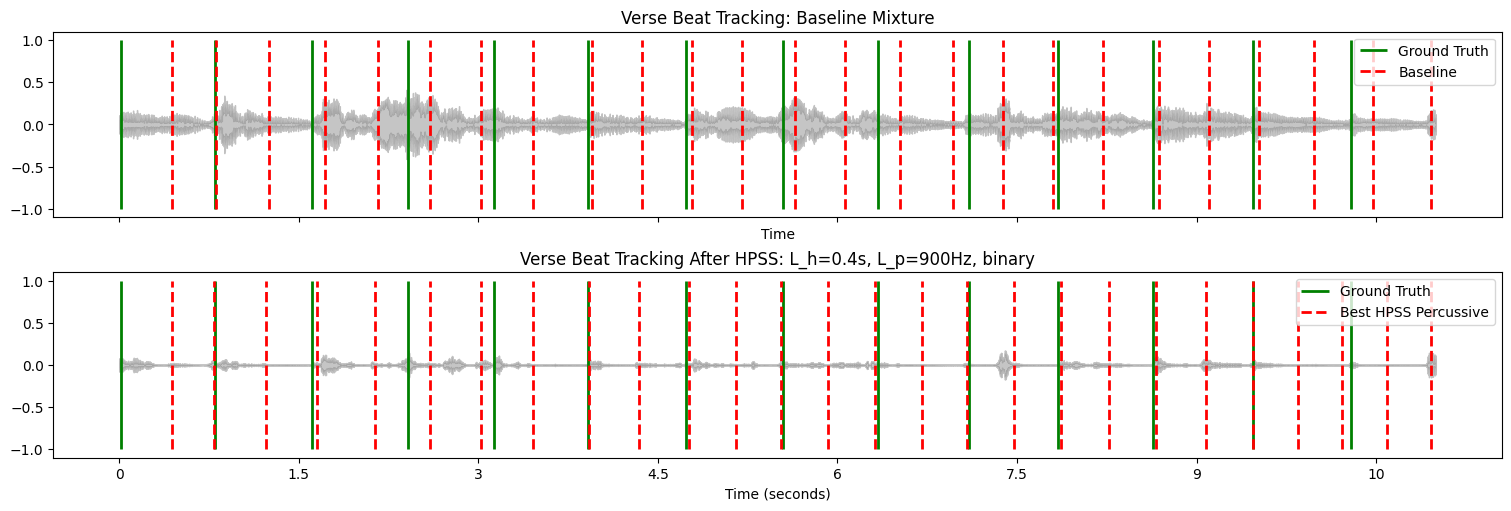

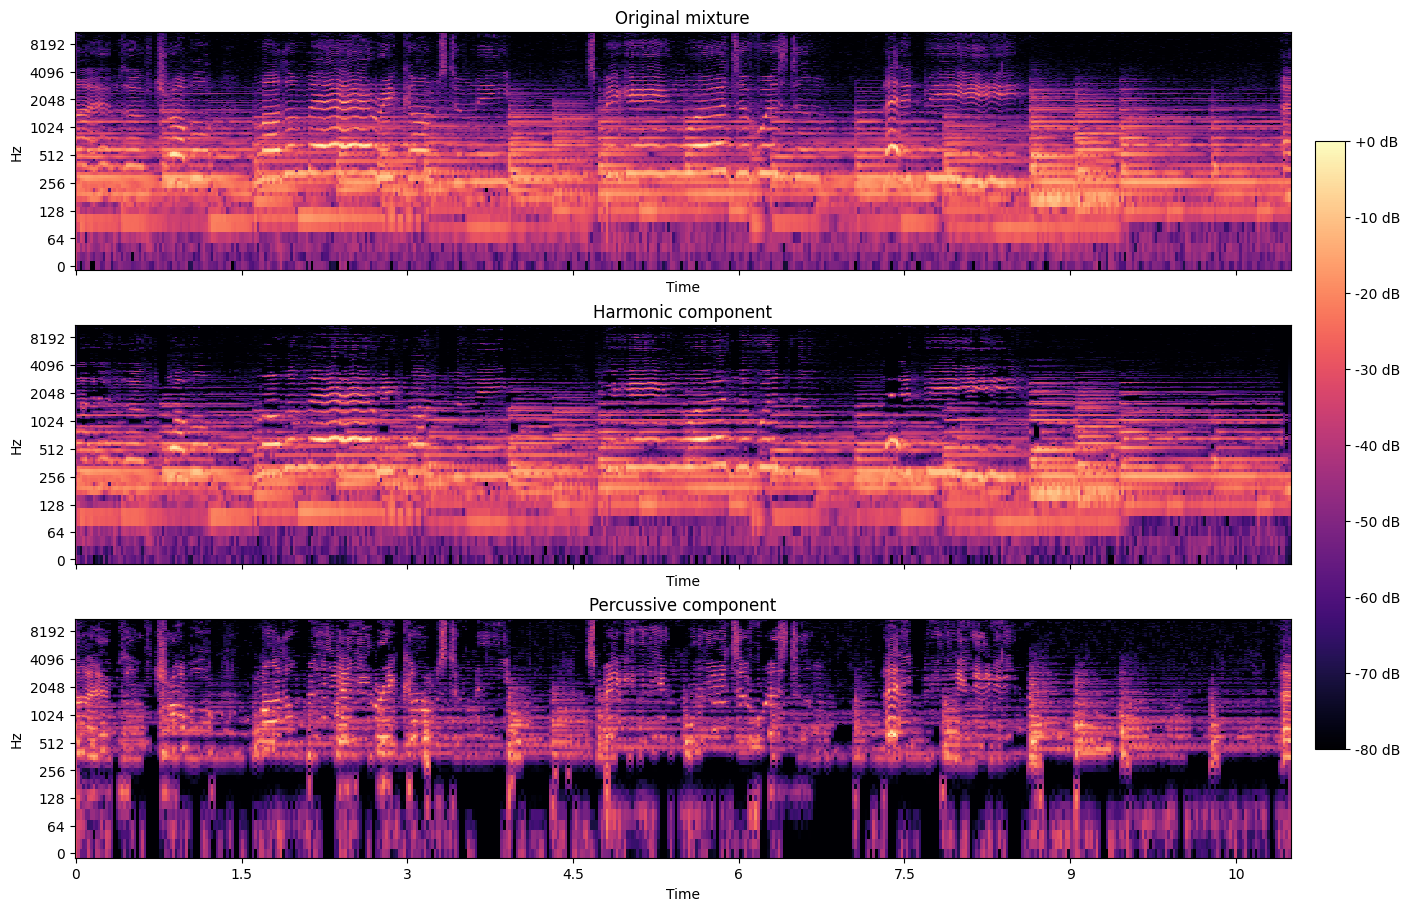

In [18]:
# Visualize baseline vs. best HPSS beat tracking and the separated spectrograms
best_label = best['setting']
y_h_best, y_p_best = separated_audio[best_label]

fig, ax = plt.subplots(2, 1, figsize=(15, 5), sharex=True, constrained_layout=True)

librosa.display.waveshow(y_verse, sr=sr, alpha=0.45, color='gray', ax=ax[0])
ax[0].vlines(gt_beats_verse, -1, 1, color='g', linewidth=2, label='Ground Truth')
ax[0].vlines(baseline_result['beat_times'], -1, 1, color='r', linestyle='--', linewidth=2, label='Baseline')
ax[0].set_title('Verse Beat Tracking: Baseline Mixture')
ax[0].legend(loc='upper right')

librosa.display.waveshow(y_p_best, sr=sr, alpha=0.45, color='gray', ax=ax[1])
ax[1].vlines(gt_beats_verse, -1, 1, color='g', linewidth=2, label='Ground Truth')
ax[1].vlines(best_result['beat_times'], -1, 1, color='r', linestyle='--', linewidth=2, label='Best HPSS Percussive')
ax[1].set_title(f"Verse Beat Tracking After HPSS: {best_label}")
ax[1].set_xlabel('Time (seconds)')
ax[1].legend(loc='upper right')
plt.show()

signals = [
    ('Original mixture', y_verse),
    ('Harmonic component', y_h_best),
    ('Percussive component', y_p_best),
]

fig, ax = plt.subplots(3, 1, figsize=(14, 9), sharex=True, constrained_layout=True)
for axis, (title, audio) in zip(ax, signals):
    S_db = librosa.amplitude_to_db(
        np.abs(librosa.stft(audio, n_fft=n_fft, hop_length=hop_length)),
        ref=np.max,
    )
    img = librosa.display.specshow(
        S_db,
        sr=sr,
        hop_length=hop_length,
        x_axis='time',
        y_axis='log',
        ax=axis,
        cmap='magma',
    )
    axis.set_title(title)
fig.colorbar(img, ax=ax, format='%+2.0f dB', fraction=0.025, pad=0.02)
plt.show()

# sonify the estimated beat
gt_beat_label_slice = gt_beat_label[(gt_beat_label >= 0) & (gt_beat_label <= 30)]
y_beats = librosa.clicks(times=gt_beat_label_slice, sr=sr, click_freq=1000, length=len(y_slice))

# # Optional listening checks
# print('Original mixture')
# ipd.display(ipd.Audio(y_verse + y_beats, rate=sr))
# print('Best harmonic component')
# ipd.display(ipd.Audio(y_h_best + y_beats, rate=sr))
# print('Best percussive component used for beat tracking')
# ipd.display(ipd.Audio(y_p_best + y_beats, rate=sr))


## Apply tempo-prior to solve “octave errors”

Reference tempo from annotations: 75.19 BPM


,method,source,prior,center_bpm,sigma_octaves,tightness,tempo,n_beats,F-measure,CMLc,CMLt,AMLc,AMLt,tempo_ratio_to_ref,BPM difference,octave_error,F improvement
264,PLP localmax,best HPSS percussive,"PLP lognorm center=72, sigma=0.1",72,0.10,nan,76.00,14,0.8000,0.8750,0.8750,0.8750,0.8750,1.01,0.81,False,+0.2783
265,PLP localmax,best HPSS percussive,"PLP lognorm center=72, sigma=0.2",72,0.20,nan,76.00,14,0.5333,0.8750,0.8750,0.8750,0.8750,1.01,0.81,False,+0.0116
57,DP beat_track,mixture,"lognorm center=78, sigma=0.2",78,0.20,50,76.00,14,0.9333,0.8750,0.8750,0.8750,0.8750,1.01,0.81,False,+0.6476
58,DP beat_track,mixture,"lognorm center=78, sigma=0.2",78,0.20,100,76.00,14,0.9333,0.8750,0.8750,0.8750,0.8750,1.01,0.81,False,+0.6476
59,DP beat_track,mixture,"lognorm center=78, sigma=0.2",78,0.20,200,76.00,14,0.9333,0.8750,0.8750,0.8750,0.8750,1.01,0.81,False,+0.6476
77,DP beat_track,mixture,"lognorm center=84, sigma=0.35",84,0.35,50,76.00,14,0.9333,0.8750,0.8750,0.8750,0.8750,1.01,0.81,False,+0.6476
78,DP beat_track,mixture,"lognorm center=84, sigma=0.35",84,0.35,100,76.00,14,0.9333,0.8750,0.8750,0.8750,0.8750,1.01,0.81,False,+0.6476
79,DP beat_track,mixture,"lognorm center=84, sigma=0.35",84,0.35,200,76.00,14,0.9333,0.8750,0.8750,0.8750,0.8750,1.01,0.81,False,+0.6476
192,DP beat_track,best HPSS percussive,"lognorm center=78, sigma=0.2",78,0.20,50,76.00,14,0.9333,0.8750,0.8750,0.8750,0.8750,1.01,0.81,False,+0.4116
193,DP beat_track,best HPSS percussive,"lognorm center=78, sigma=0.2",78,0.20,100,76.00,14,0.9333,0.8750,0.8750,0.8750,0.8750,1.01,0.81,False,+0.4116


Best tempo-prior result:
  method/source: PLP localmax on best HPSS percussive
  prior: PLP lognorm center=72, sigma=0.1, tightness=nan
  tempo: 76.00 BPM vs reference 75.19 BPM
  F-measure: 0.8000 (+0.2783 vs same-source baseline)
  octave error solved? yes


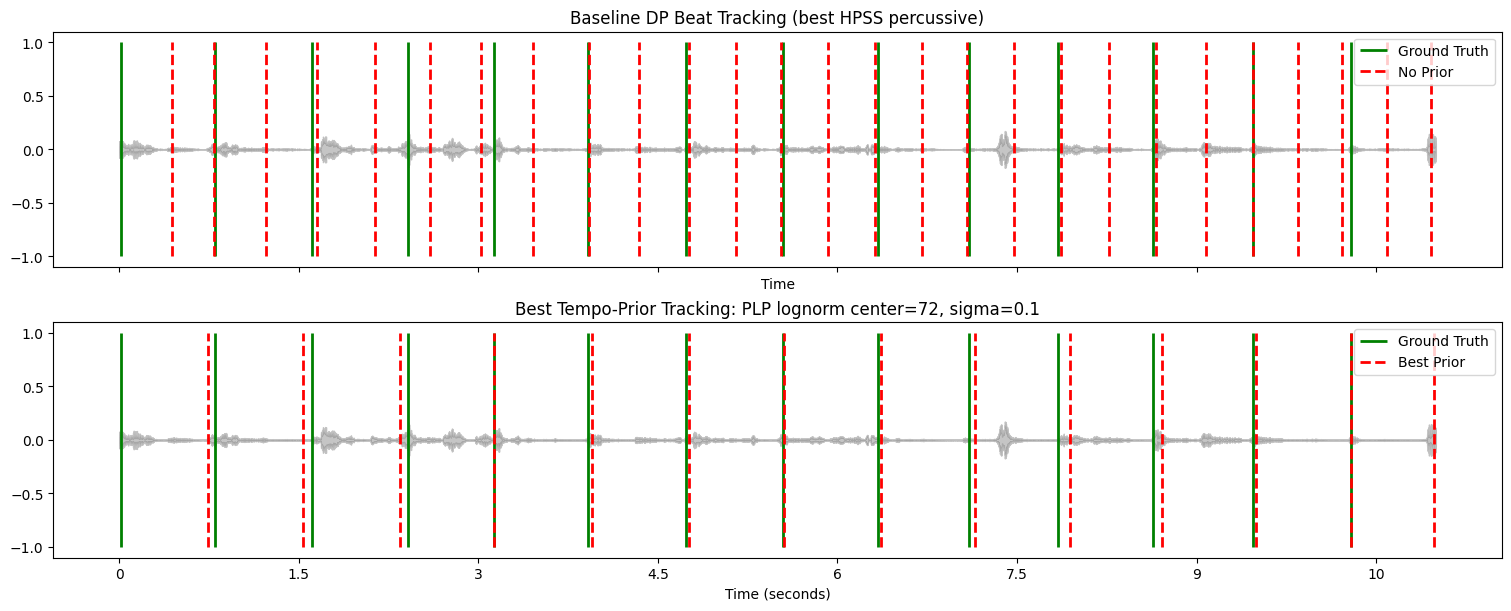

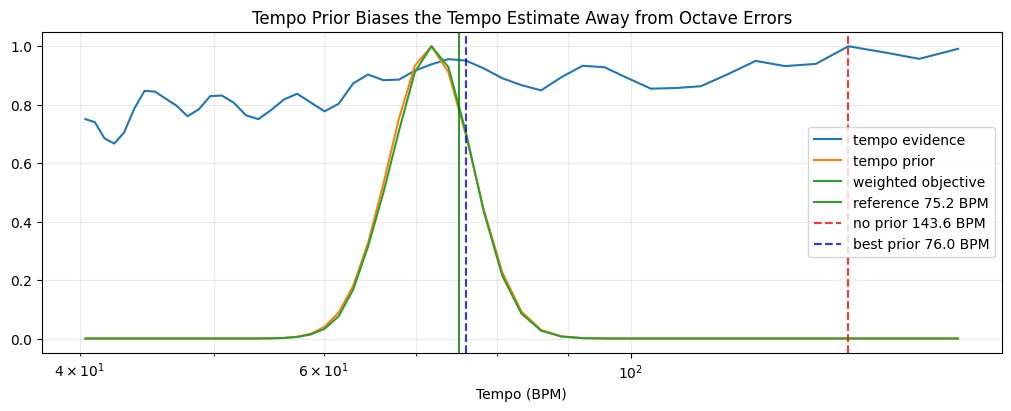

In [21]:
import scipy.stats

start_sec = 15
duration = 11
hop_length = 512

# For this verse, the reference beat annotations imply the slower musical tempo.
y_verse_prior, _ = librosa.load(AUDIO_PATH, sr=sr, offset=start_sec, duration=duration)
gt_beats_prior = gt_beat_label[(gt_beat_label >= start_sec) & (gt_beat_label <= start_sec + duration)] - start_sec
ref_iois = np.diff(gt_beats_prior)
ref_tempo = 60.0 / np.median(ref_iois)

# Compare the mixture against the best HPSS percussive signal if the HPSS cells were run.
audio_sources = {'mixture': y_verse_prior}
if 'y_p_best' in globals():
    audio_sources['best HPSS percussive'] = y_p_best


def make_lognorm_prior(center_bpm, sigma_octaves):
    """Log-normal prior centered at center_bpm; sigma is measured in octaves."""
    sigma_natural_log = sigma_octaves * np.log(2)
    return scipy.stats.lognorm(s=sigma_natural_log, scale=center_bpm)


def evaluate_beats(ref_beats, est_beats):
    scores = mir_eval.beat.evaluate(ref_beats, est_beats)
    return {
        'F-measure': scores['F-measure'],
        'CMLc': scores['Correct Metric Level Continuous'],
        'CMLt': scores['Correct Metric Level Total'],
        'AMLc': scores['Any Metric Level Continuous'],
        'AMLt': scores['Any Metric Level Total'],
    }


def run_dp_tracker(audio, source_name, prior_label='none', prior=None, tightness=100):
    onset_env = librosa.onset.onset_strength(y=audio, sr=sr, hop_length=hop_length)
    tempo, beat_frames = librosa.beat.beat_track(
        onset_envelope=onset_env,
        sr=sr,
        hop_length=hop_length,
        prior=prior,
        tightness=tightness,
    )
    beat_times = librosa.frames_to_time(beat_frames, sr=sr, hop_length=hop_length)
    row = {
        'method': 'DP beat_track',
        'source': source_name,
        'prior': prior_label,
        'center_bpm': np.nan,
        'sigma_octaves': np.nan,
        'tightness': tightness,
        'tempo': float(np.atleast_1d(tempo)[0]),
        'n_beats': len(beat_times),
        'beat_times': beat_times,
    }
    row.update(evaluate_beats(gt_beats_prior, beat_times))
    return row


def run_plp_tracker(audio, source_name, prior_label, prior):
    onset_env = librosa.onset.onset_strength(y=audio, sr=sr, hop_length=hop_length)
    pulse = librosa.beat.plp(
        onset_envelope=onset_env,
        sr=sr,
        hop_length=hop_length,
        prior=prior,
        tempo_min=40,
        tempo_max=180,
    )
    beat_frames = np.flatnonzero(librosa.util.localmax(pulse))
    beat_times = librosa.frames_to_time(beat_frames, sr=sr, hop_length=hop_length)
    estimated_tempo = 60.0 / np.median(np.diff(beat_times)) if len(beat_times) > 1 else 0.0
    row = {
        'method': 'PLP localmax',
        'source': source_name,
        'prior': prior_label,
        'center_bpm': np.nan,
        'sigma_octaves': np.nan,
        'tightness': np.nan,
        'tempo': estimated_tempo,
        'n_beats': len(beat_times),
        'beat_times': beat_times,
    }
    row.update(evaluate_beats(gt_beats_prior, beat_times))
    return row


prior_centers = [60, 66, 72, 78, 84, 90, 110, 120]
prior_widths = [0.05, 0.10, 0.20, 0.35]
tightness_values = [50, 100, 200, 400]

prior_results = []

for source_name, audio in audio_sources.items():
    # Baseline DP with no prior, for octave-error comparison.
    prior_results.append(run_dp_tracker(audio, source_name, prior_label='none', prior=None, tightness=100))

    for center_bpm in prior_centers:
        for sigma_octaves in prior_widths:
            prior = make_lognorm_prior(center_bpm, sigma_octaves)
            label = f'lognorm center={center_bpm}, sigma={sigma_octaves}'
            for tightness in tightness_values:
                row = run_dp_tracker(audio, source_name, label, prior=prior, tightness=tightness)
                row['center_bpm'] = center_bpm
                row['sigma_octaves'] = sigma_octaves
                prior_results.append(row)

    # PLP documentation recommends a scipy.stats prior object; local maxima give beat times.
    for center_bpm in [72, 84, 120]:
        for sigma_octaves in [0.10, 0.20]:
            prior = make_lognorm_prior(center_bpm, sigma_octaves)
            label = f'PLP lognorm center={center_bpm}, sigma={sigma_octaves}'
            row = run_plp_tracker(audio, source_name, label, prior=prior)
            row['center_bpm'] = center_bpm
            row['sigma_octaves'] = sigma_octaves
            prior_results.append(row)

prior_df = pd.DataFrame(prior_results)
prior_df['tempo_ratio_to_ref'] = prior_df['tempo'] / ref_tempo
prior_df['BPM difference'] = np.abs(prior_df['tempo'] - ref_tempo)
prior_df['octave_error'] = np.minimum(
    np.abs(prior_df['tempo_ratio_to_ref'] - 2.0),
    np.abs(prior_df['tempo_ratio_to_ref'] - 0.5),
) < 0.20
prior_df['F improvement'] = prior_df.groupby('source')['F-measure'].transform(lambda s: s - s.iloc[0])

prior_summary = prior_df.drop(columns=['beat_times']).sort_values(
    ['BPM difference', 'F-measure', 'CMLc'],
    ascending=[True, False, False],
)

print(f'Reference tempo from annotations: {ref_tempo:.2f} BPM')
display(prior_summary.head(20).style.format({
    'center_bpm': '{:.0f}',
    'sigma_octaves': '{:.2f}',
    'tightness': '{:.0f}',
    'tempo': '{:.2f}',
    'tempo_ratio_to_ref': '{:.2f}',
    'BPM difference': '{:.2f}',
    'F-measure': '{:.4f}',
    'CMLc': '{:.4f}',
    'CMLt': '{:.4f}',
    'AMLc': '{:.4f}',
    'AMLt': '{:.4f}',
    'F improvement': '{:+.4f}',
}))

best_prior = prior_df.sort_values(
    ['BPM difference', 'F-measure', 'CMLc'],
    ascending=[True, False, False],
).iloc[0]
source_baseline = prior_df[(prior_df['source'] == best_prior['source']) & (prior_df['prior'] == 'none')].iloc[0]

print('Best tempo-prior result:')
print(f"  method/source: {best_prior['method']} on {best_prior['source']}")
print(f"  prior: {best_prior['prior']}, tightness={best_prior['tightness']}")
print(f"  tempo: {best_prior['tempo']:.2f} BPM vs reference {ref_tempo:.2f} BPM")
print(f"  F-measure: {best_prior['F-measure']:.4f} ({best_prior['F-measure'] - source_baseline['F-measure']:+.4f} vs same-source baseline)")
print(f"  octave error solved? {'yes' if not best_prior['octave_error'] else 'no'}")

fig, ax = plt.subplots(2, 1, figsize=(15, 6), sharex=True, constrained_layout=True)
plot_audio = audio_sources[best_prior['source']]
librosa.display.waveshow(plot_audio, sr=sr, alpha=0.45, color='gray', ax=ax[0])
ax[0].vlines(gt_beats_prior, -1, 1, color='g', linewidth=2, label='Ground Truth')
ax[0].vlines(source_baseline['beat_times'], -1, 1, color='r', linestyle='--', linewidth=2, label='No Prior')
ax[0].set_title(f"Baseline DP Beat Tracking ({best_prior['source']})")
ax[0].legend(loc='upper right')

librosa.display.waveshow(plot_audio, sr=sr, alpha=0.45, color='gray', ax=ax[1])
ax[1].vlines(gt_beats_prior, -1, 1, color='g', linewidth=2, label='Ground Truth')
ax[1].vlines(best_prior['beat_times'], -1, 1, color='r', linestyle='--', linewidth=2, label='Best Prior')
ax[1].set_title(f"Best Tempo-Prior Tracking: {best_prior['prior']}")
ax[1].set_xlabel('Time (seconds)')
ax[1].legend(loc='upper right')
plt.show()

# Visualize how the tempo prior changes the tempo objective.
onset_env = librosa.onset.onset_strength(y=plot_audio, sr=sr, hop_length=hop_length)
tg = librosa.feature.tempogram(onset_envelope=onset_env, sr=sr, hop_length=hop_length)
autocorr = np.mean(tg, axis=1)
bpms = librosa.tempo_frequencies(len(autocorr), sr=sr, hop_length=hop_length)
valid = (bpms >= 40) & (bpms <= 180)
if np.isfinite(best_prior['center_bpm']):
    prior_curve = make_lognorm_prior(best_prior['center_bpm'], best_prior['sigma_octaves']).pdf(bpms)
else:
    prior_curve = np.ones_like(bpms)
weighted_objective = autocorr * prior_curve

fig, ax = plt.subplots(figsize=(10, 4), constrained_layout=True)
ax.semilogx(bpms[valid], librosa.util.normalize(autocorr[valid]), label='tempo evidence')
ax.semilogx(bpms[valid], librosa.util.normalize(prior_curve[valid]), label='tempo prior')
ax.semilogx(bpms[valid], librosa.util.normalize(weighted_objective[valid]), label='weighted objective')
ax.axvline(ref_tempo, color='g', linestyle='-', alpha=0.8, label=f'reference {ref_tempo:.1f} BPM')
ax.axvline(source_baseline['tempo'], color='r', linestyle='--', alpha=0.8, label=f'no prior {source_baseline["tempo"]:.1f} BPM')
ax.axvline(best_prior['tempo'], color='b', linestyle='--', alpha=0.8, label=f'best prior {best_prior["tempo"]:.1f} BPM')
ax.set_xlabel('Tempo (BPM)')
ax.set_title('Tempo Prior Biases the Tempo Estimate Away from Octave Errors')
ax.grid(True, which='both', alpha=0.25)
ax.legend(loc='best')
plt.show()


# Chord Recognition by HMM

Let's do chord recognition with the template-basd approach.

In [ ]:
import librosa, libfmp.b, libfmp.c5, libfmp.c4, mir_eval
import numpy as np, pandas as pd, requests, io, matplotlib.pyplot as plt

# audio_url = "https://www.audiolabs-erlangen.de/resources/MIR/FMP/data/C5/FMP_C5_Audio_Beatles_LetItBe_Beatles_1970-LetItBe-06.wav"
chord_url = "https://www.audiolabs-erlangen.de/resources/MIR/FMP/data/C5/FMP_C5_Audio_Beatles_LetItBe_Beatles_1970-LetItBe-06_Chords_simplified.csv"

start_sec = 15
duration = 11
end_sec = start_sec+duration
sr = 22050
# y, sr = librosa.load(io.BytesIO(requests.get(audio_url).content), sr=sr, offset=start_sec, duration=duration)
y, sr = librosa.load(AUDIO_PATH, sr=sr, offset=start_sec, duration=duration)

# take the chord labels
ann_all, _ = libfmp.c4.read_structure_annotation(io.BytesIO(requests.get(chord_url).content))
ann = []
for s in ann_all:
    if s[1] > start_sec and s[0] < end_sec:
        new_start = max(0, s[0] - start_sec)
        new_end = min(duration, s[1] - start_sec)
        ann.append([new_start, new_end, s[2]])

# extract the chroma feature
hop_length = 512
chroma = librosa.feature.chroma_cqt(y=y, sr=sr, hop_length=hop_length)

# caculate time intervals for frame-level prediction
frames = np.arange(chroma.shape[1])
frame_times = librosa.frames_to_time(frames, sr=sr, hop_length=hop_length)
frame_intervals = np.vstack([frame_times, np.append(frame_times[1:], duration)]).T

## template-based approach
chord_labels = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B',
                'C:min', 'C#:min', 'D:min', 'D#:min', 'E:min', 'F:min', 'F#:min', 'G:min', 'G#:min', 'A:min', 'A#:min', 'B:min']
chord_sim, chord_binary_temp = libfmp.c5.chord_recognition_template(chroma, norm_sim='1')

# obtain chord labels as text
chord_id_temp = np.argmax(chord_binary_temp, axis=0)
est_labels_temp = [chord_labels[i] for i in chord_id_temp]

# merge frame-level time intervals to segment-level time intervals based on chord predictions
est_temp_seg = mir_eval.chord.merge_chord_intervals(frame_intervals, est_labels_temp)

# take segment-level chord predictions
from itertools import groupby
est_labels_temp = [key for key, group in groupby(est_labels_temp)]

# evluation
def calculate_metrics(ref_int, ref_lab, est_int, est_lab):
    scores = mir_eval.chord.evaluate(ref_int, ref_lab, est_int, est_lab)
    score_csr = scores['majmin']
    score_seg = scores["seg"]
    return score_csr, score_seg

ref_intervals = np.array([[a[0], a[1]] for a in ann])
ref_labels = [a[2] for a in ann]

score_csr_temp, score_seg_temp = calculate_metrics(ref_intervals, ref_labels, est_temp_seg, est_labels_temp)

print(f"--- Evaluation Results ---")
print(f"[Template] CSR: {score_csr_temp:.4f} | Segmentation_Accuracy: {score_seg_temp:.4f}")

### Visualize the chord predictions ###
fig, ax = plt.subplots(4, 1, figsize=(12, 8), sharex=True, gridspec_kw={'height_ratios': [1.5, 2.5, 1, 1]})

# (1) Chromagram (Input)
img0 = librosa.display.specshow(chroma, x_axis='time', y_axis='chroma', ax=ax[0], hop_length=hop_length)
ax[0].set_title('1. Chromagram (Input Feature)')
fig.colorbar(img0, ax=ax[0])

# (2) Chord Similarity Matrix (Emission)
img1 = librosa.display.specshow(chord_sim, x_axis='time', ax=ax[1], hop_length=hop_length)
ax[1].set_yticks(np.arange(len(chord_labels)))
ax[1].set_yticklabels(chord_labels, fontsize=7)
ax[1].set_title('2. Chord Similarity Matrix (Observation)')
fig.colorbar(img1, ax=ax[1])

# (3) Ground Truth
libfmp.b.plot_segments(ann, ax=ax[2])
ax[2].set_title('3. Ground Truth (Reference)')

# make the chord prediction format the same as that of the ground truth
est_temp_seg2 = [[i[0], i[1], l] for i, l in zip(est_temp_seg, est_labels_temp)]

# (4) Template Result
libfmp.b.plot_segments(est_temp_seg2, ax=ax[3])
ax[3].set_title(f'4. Template-based Prediction')

plt.xlim([0, duration])
plt.tight_layout()
plt.show()



The accuracy is not very low but there are many sudden jumps between chord predictions (the segmentation accuracy is low).

So, let's implement the HMM-based approach to have more smooth predictions and higher accuracy.